In [1]:
import sys
from pathlib import Path
import pandas as pd

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts.rq9_function_lib import display_weather_codes_per_region, run_volatility_panel_regression


In [2]:
weather_path = Path(r'/Users/sebastian/data-science-projekt/weather_per_leitregion')
region_price_path = Path(r'/Users/sebastian/data-science-projekt/tankerkoenig_data/regions_avg_prices_per_year')
region_coord_path = Path(r'/Users/sebastian/data-science-projekt/plz_leitregionen.csv')
weather_codes_file = Path(r'/Users/sebastian/data-science-projekt/weather_codes_descriptions.csv')
extreme_code_file = Path(r'/Users/sebastian/data-science-projekt/extreme_weather_codes_copy.csv')

# What impact do extreme weather conditions have on the fuel price volatility?

Before testing a possible influence of **extreme weather events**, we had to define what conditions we will consider as "extreme weather". The open-meteo api provides a number of codes that describe specific weather conditions. We decided to consider the following weather events as **"extreme"**: heavy drizzle, freezing drizzle, heavy rain, freezing rain, snow, heavy snow, heavy showers, thunderstorm, light thunderstorm with hail, thunderstorm with hail.
Furthermore, we used the german post code **"Leitregionen"** (see map below) to split up all the gas stations into regions with similar weather conditions.

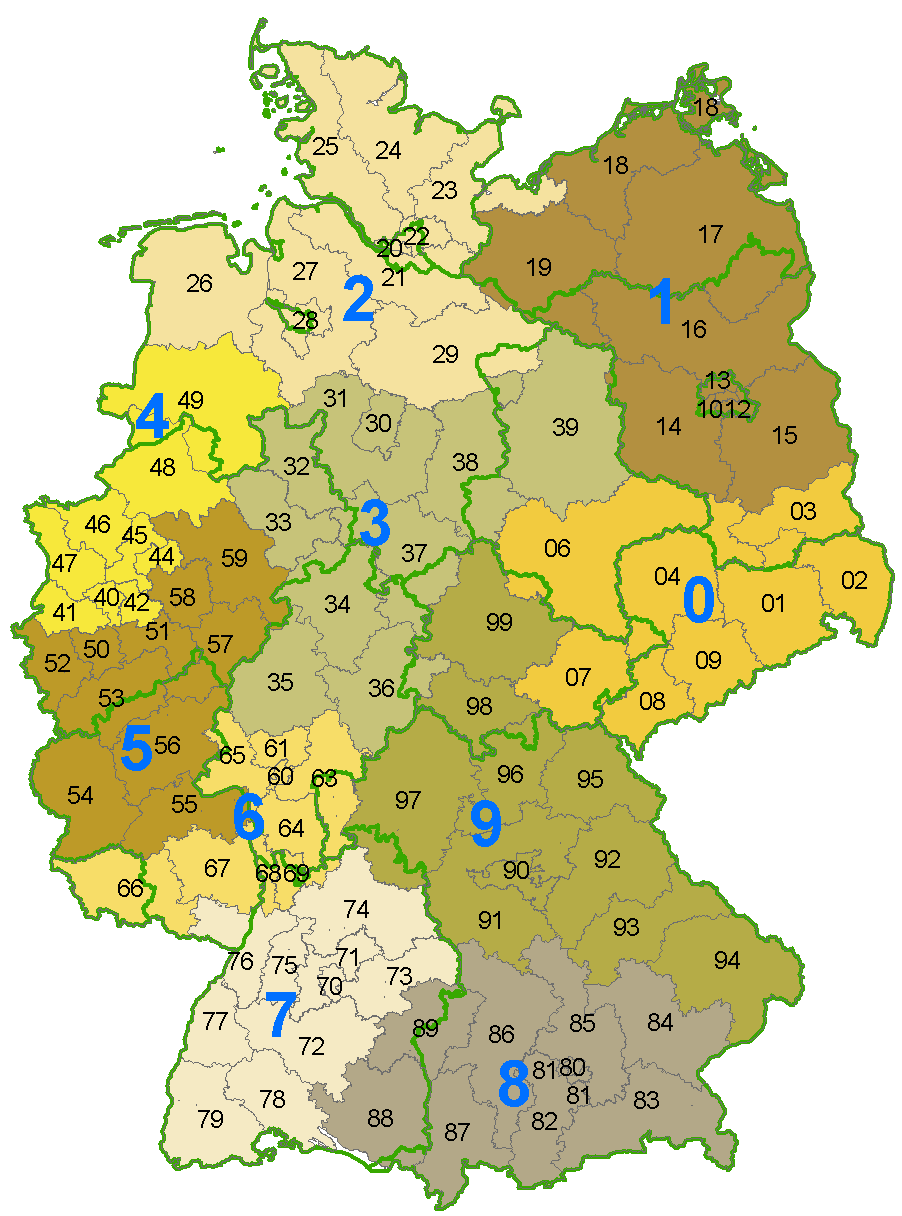

For an otherview over the weather codes, lets display the codes over a year for a specific region.

In [7]:
year = 2025
region = "24" #Kiel region
display_weather_codes_per_region(weather_path,weather_codes_file,region,year)

As we can see in this example, there are not that many extreme weather events that could influence the price volatility. 
In the following section we will test wether these extreme events have an impact on the price volatility anyways.

For the panel regression we have calculated the **median price** (hourly) for each region. For practical reasons, we calculated for each regions its geographical centre and then retrieved the weather data for these coordinates.

In [4]:
regions_df = pd.read_csv(region_coord_path, dtype={"leit_plz":str}) 
regions = regions_df["leit_plz"].to_list()

This regression examines whether **extreme weather events** are associated with
higher **price volatility** in a panel setting.

The dependent variable is a rolling mean absolute deviation (MAD) of price
changes. Letting $\Delta P_t = P_t - P_{t-1}$, the volatility measure is

$$
\text{MAD}_t = \frac{1}{w} \sum_{j=0}^{w-1}
\left| \Delta P_{t-j} - \overline{\Delta P}_t \right|
$$

where $w$ is the rolling window length and $\overline{\Delta P}_t$ is the
rolling mean of price changes within that window.

The regression model from AbsorbingLS can be written in the general form

$$
y_i = x_i \beta + z_i \gamma + \epsilon_i
$$

where $y_i$ is the volatility measure, $x_i$ is the regressor of interest, and $z_i$ collects the fixed effects.

In our application, this corresponds to

$$
\text{volatility}_{r,t}
=
\beta \cdot \text{extreme\_weather}_{r,t}
+ \alpha_r
+ \delta_d
+ \eta_h
+ \varepsilon_{r,t}
$$

where $\alpha_r$ denotes region fixed effects, $\delta_d$ date fixed effects,
and $\eta_h$ hour fixed effects.

$\beta$ is our coefficient of interest, which captures the association
between extreme weather events and fuel price volatility after controlling for region,
date, and hour effects. Standard errors are clustered at the region level.

Please note that this regression only tests the diesel median. The method also works with the other fuel type and other statistic (mean), you just have to change the respective input parameter. Since the results for all were insignificant and very small, we decided to only show this one example.

In [5]:
model = run_volatility_panel_regression(region_price_path,weather_path,regions,extreme_code_file)

                         Absorbing LS Estimation Summary                          
Dep. Variable:             volatility   R-squared:                          0.2415
Estimator:               Absorbing LS   Adj. R-squared:                     0.2411
No. Observations:             8679732   F-statistic:                        0.2842
Date:                Tue, Mar 17 2026   P-value (F-stat):                   0.5940
Time:                        16:26:55   Distribution:                      chi2(1)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0000
                                        Variables Absorbed:                 4394.0
                                Parameter Estimates                                
                 Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------
extreme_weather -2.426e-05  4.551e-05    -0.5331     0.5940     -0.0001   6.493e-05


#### Result:

The coefficient on **extreme_weather** is negative but statistically
insignificant ($\hat{\beta} = -2.426 \times 10^{-5}$, $p = 0.594 >> 0.05$). 

This indicates that, after controlling for region, date, and hour fixed effects, the
analysis does not find evidence of a systematic association between extreme
weather events and the rolling mean absulute deviation of price volatility.

The estimated effect is very small in magnitude, and the confidence interval
includes both negative and positive values, suggesting that the true effect may
be close to zero.